# Orange County Analysis

In [1]:
# Import statements
import pandas as pd
import numpy as np  # noqa: F401

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [2]:
from data_utils import load_census, census_rollup

In [3]:
# Load in policing data
original_policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2022_2024.csv", low_memory=False)

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

In [4]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [5]:
# Load in census data
census = load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Policing Analysis

In [7]:
from data_utils import add_standardized_race
from rates_utils import policing_rates
from table_utils import fmt_est_ci, make_pivot_with_ci
from visualization_utils import visualize_policing, export_figure_to_pdf

In [8]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["action_any_search"] & policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
# Hits only count as hits if they were found in a search, and the search was discretionary
policing["disc_hit"] = (
    policing["disc_search"] & # Has to be from a discretionary search
    policing["action_any_search"].fillna(False) & # Has to have been searched
    (policing["contraband_any"] == 1)
)

# Create a copy with all people involved in stops for sensitivity analysis
policing_multi = policing.copy()

# Filter for person 1 for each stop (usually, the main person stopped, but not always)
policing = policing[policing["person_number"] == 1].copy()

policing_analysis = policing_rates(policing, census_coarse)

In [9]:
# Creating tables
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]

df = policing_analysis.copy()

pop = (df[["Perceived Race", "Population"]]
       .drop_duplicates("Perceived Race")
       .set_index("Perceived Race")
       .reindex(race_order))

stops_1k = make_pivot_with_ci(df, "Stops per 1,000", "Stops per 1,000 SE")
searches_1k = make_pivot_with_ci(df, "Searches per 1,000", "Searches per 1,000 SE")

In [10]:
table1 = pd.concat(
    [pop, stops_1k, searches_1k],
    axis=1,
    keys=["Population", "Stops per 1,000", "Searches per 1,000"]
)


table1.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table1.columns],
    names=["", "Year"]
)

table1

Population Stops per 1,000                  \
Year                   Population            2022            2023   
Perceived Race                                                      
Black/African American      49304  176.88 (±3.71)  158.14 (±3.51)   
Hispanic/Latino           1086834   65.75 (±0.48)   58.48 (±0.45)   
White                     1198655   52.00 (±0.41)   44.19 (±0.38)   
Asian                      699124   28.52 (±0.40)   26.03 (±0.38)   
Other                      153072   69.77 (±1.32)   61.83 (±1.25)   

                                       Searches per 1,000                 \
Year                              2024               2022           2023   
Perceived Race                                                             
Black/African American  180.70 (±3.75)      16.33 (±1.13)  13.49 (±1.03)   
Hispanic/Latino          71.35 (±0.50)       5.89 (±0.14)   5.41 (±0.14)   
White                    51.89 (±0.41)       3.12 (±0.10)   2.47 (±0.09)   
Asian                    29.96 (±0.41)       0.73 (±0.06)   0.67 (±0.06)   
Other                    80.77 (±1.42)       1.91 (±0.22)   1.57 (±0.20)   

                                       
Year                             2024  
Perceived Race                         
Black/African American  15.76 (±1.11)  
Hispanic/Latino          7.06 (±0.16)  
White                    3.02 (±0.10)  
Asian                    0.71 (±0.06)  
Other                    2.44 (±0.25)

In [11]:
tab2 = df.copy()

# Convert proportions to percentages
tab2["Search Rate"] *= 100
tab2["Hit Rate"] *= 100
tab2["Search Rate SE"] *= 100
tab2["Hit Rate SE"] *= 100

search_rate = make_pivot_with_ci(tab2, "Search Rate", "Search Rate SE")
hit_rate    = make_pivot_with_ci(tab2, "Hit Rate", "Hit Rate SE")

table2 = pd.concat([search_rate, hit_rate], axis=1, keys=["Search Rate (%)", "Hit Rate (%)"])

table2.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table2.columns],
    names=["", "Year"]
)

table2 = table2.reindex(race_order)
table2

Search Rate (%)                              \
Year                              2022          2023          2024   
Perceived Race                                                       
Black/African American    9.23 (±0.61)  8.53 (±0.62)  8.72 (±0.59)   
Hispanic/Latino           8.96 (±0.21)  9.25 (±0.23)  9.89 (±0.21)   
White                     6.01 (±0.19)  5.58 (±0.20)  5.81 (±0.18)   
Asian                     2.57 (±0.22)  2.59 (±0.23)  2.37 (±0.21)   
Other                     2.74 (±0.31)  2.55 (±0.32)  3.02 (±0.30)   

                         Hit Rate (%)                                
Year                             2022           2023           2024  
Perceived Race                                                       
Black/African American  29.19 (±3.14)  25.11 (±3.30)  24.58 (±3.03)  
Hispanic/Latino         30.72 (±1.13)  27.52 (±1.14)  25.60 (±0.98)  
White                   37.06 (±1.55)  37.62 (±1.75)  33.91 (±1.54)  
Asian                   31.97 (±4.04)  30.36 (±4.15)  30.78 (±4.06)  
Other                   29.01 (±5.20)  23.65 (±5.37)  25.94 (±4.44)

In [ ]:
policing_figs = visualize_policing(policing_analysis)

# export_figure_to_pdf(policing_figs["stops"], "stops")
# export_figure_to_pdf(policing_figs["search_comparison"], "search_comparison")
# export_figure_to_pdf(policing_figs["hit_rate"], "hit_rate")

Saved: stops.pdf
Saved: search_comparison.pdf
Saved: hit_rate.pdf


# Policing Sensitivity Analysis: Mixed Search Bases

In [14]:
from rates_utils import policing_rates_sensitivity
from visualization_utils import create_sensitivity_visualization

In [15]:
# Create alternative classification: treat mixed searches as discretionary
policing["disc_search_mixed"] = policing["action_any_search"] & policing["search_type"].isin(["Discretionary only", "Mixed", "No search basis"])

# Create discretionary search indicator
policing["disc_hit_mixed"] = (
    policing["disc_search_mixed"] & # Cannot be from a non-discretionary search
    policing["action_any_search"].fillna(False) & # Has to have been searched
    (policing["contraband_any"] == 1)
)

# Compute policing rates using mixed classification
policing_analysis_mixed = policing_rates_sensitivity(policing, census_coarse, "mixed")

In [16]:
def make_2024_block(df, label):
    """Return a 2024 table with formatted Search/Hit rates for one method."""
    d = df[df["Year"] == 2024].copy()

    out = pd.DataFrame(index=d["Perceived Race"])
    out[( "Search Rate (%)", label)] = [fmt_est_ci(e, s, 2) for e, s in zip(d["Search Rate"], d["Search Rate SE"])]
    out[( "Hit Rate (%)",    label)] = [fmt_est_ci(e, s, 2) for e, s in zip(d["Hit Rate"],    d["Hit Rate SE"])]
    return out

# Make safe copies
strict_df = policing_analysis.copy()
mixed_df  = policing_analysis_mixed.copy()

# Convert to percentages ONLY if stored as proportions
for d in (strict_df, mixed_df):
    if d["Search Rate"].max() <= 1:
        d[["Search Rate", "Hit Rate",
           "Search Rate SE", "Hit Rate SE"]] *= 100

strict_2024 = make_2024_block(strict_df, "Strict")
mixed_2024  = make_2024_block(mixed_df, "Mixed")

table3 = strict_2024.join(mixed_2024, how="outer")

# Enforce race order
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]
table3 = table3.reindex(race_order)

table3 = table3[[("Search Rate (%)","Strict"), ("Search Rate (%)","Mixed"),
                 ("Hit Rate (%)","Strict"),    ("Hit Rate (%)","Mixed")]]

table3.columns = pd.MultiIndex.from_tuples(table3.columns, names=["", ""])
table3.index.name = "Perceived Race"

table3

Search Rate (%)                  Hit Rate (%)  \
                                Strict          Mixed         Strict   
Perceived Race                                                         
Black/African American    8.72 (±0.59)  12.46 (±0.69)  24.58 (±3.03)   
Hispanic/Latino           9.89 (±0.21)  13.15 (±0.24)  25.60 (±0.98)   
White                     5.81 (±0.18)   8.09 (±0.21)  33.91 (±1.54)   
Asian                     2.37 (±0.21)   3.13 (±0.24)  30.78 (±4.06)   
Other                     3.02 (±0.30)   3.92 (±0.34)  25.94 (±4.44)   

                                       
                                Mixed  
Perceived Race                         
Black/African American  28.92 (±2.67)  
Hispanic/Latino         30.50 (±0.89)  
White                   38.79 (±1.35)  
Asian                   35.06 (±3.65)  
Other                   27.63 (±3.98)

In [ ]:
# Create the sensitivity analysis figure
sensitivity_fig = create_sensitivity_visualization(
    strict_df=policing_analysis,
    mixed_df=policing_analysis_mixed,
    strict_name="Strict",
    mixed_name="Mixed",
    title_ending="Search Classification"
)

# export_figure_to_pdf(sensitivity_fig, "strict_mixed_sensitivity")

Saved: strict_mixed_sensitivity.pdf


# Policing Sensitivity Analysis: Multi-Person Stops

In [18]:
# Rename column
policing_multi.rename(columns={"disc_search": "disc_search_multiperson"}, inplace=True)

# Create discretionary search indicator
policing_multi["disc_hit_multiperson"] = (
    policing_multi["disc_search_multiperson"] & # Cannot be from a non-discretionary search
    policing_multi["action_any_search"].fillna(False) & # Has to have been searched
    (policing_multi["contraband_any"] == 1)
)

# Compute policing rates using all people involved in stops, not just the first person listed
policing_analysis_multiperson = policing_rates_sensitivity(policing_multi, census_coarse, "multiperson")

# Make safe copies
solo_df = policing_analysis.copy()
multiperson_df  = policing_analysis_multiperson.copy()

# Convert to percentages ONLY if stored as proportions
for d in (solo_df, multiperson_df):
    if d["Search Rate"].max() <= 1:
        d[["Search Rate", "Hit Rate",
           "Search Rate SE", "Hit Rate SE"]] *= 100

solo_2024 = make_2024_block(solo_df, "Solo")
multiperson_2024  = make_2024_block(multiperson_df, "Multiperson")

table4 = solo_2024.join(multiperson_2024, how="outer")

# Enforce race order
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]
table4 = table4.reindex(race_order)

table4 = table4[[("Search Rate (%)","Solo"), ("Search Rate (%)","Multiperson"),
                 ("Hit Rate (%)","Solo"),    ("Hit Rate (%)","Multiperson")]]

table4.columns = pd.MultiIndex.from_tuples(table4.columns, names=["", ""])
table4.index.name = "Perceived Race"

table4

Search Rate (%)                  Hit Rate (%)  \
                                  Solo    Multiperson           Solo   
Perceived Race                                                         
Black/African American    8.72 (±0.59)   9.40 (±0.58)  24.58 (±3.03)   
Hispanic/Latino           9.89 (±0.21)  10.80 (±0.21)  25.60 (±0.98)   
White                     5.81 (±0.18)   6.55 (±0.19)  33.91 (±1.54)   
Asian                     2.37 (±0.21)   2.52 (±0.21)  30.78 (±4.06)   
Other                     3.02 (±0.30)   3.33 (±0.31)  25.94 (±4.44)   

                                       
                          Multiperson  
Perceived Race                         
Black/African American  24.67 (±2.80)  
Hispanic/Latino         26.16 (±0.90)  
White                   34.12 (±1.41)  
Asian                   30.47 (±3.82)  
Other                   26.05 (±4.15)

In [ ]:
# Create the sensitivity analysis figure
sensitivity_multiperson_fig = create_sensitivity_visualization(
    policing_analysis,
    policing_analysis_multiperson,
    strict_name="Solo",
    mixed_name="Multiperson",
    title_ending="Stops"
)

# export_figure_to_pdf(sensitivity_multiperson_fig, "solo_multiperson_sensitivity")

Saved: solo_multiperson_sensitivity.pdf


# Prosecution Analysis: Enhancement Rates by Charge and Statute Level

In [20]:
from data_utils import categorize_charge
from rates_utils import enhancement_rates_by_primary_severity

from table_utils import (
    enhancement_rate_race_table,
    enhancement_rate_race_statute_table,
    enhancement_rate_race_statute_category_table
)

from visualization_utils import (
    plot_enhancement_rate_by_race,
    plot_enhancement_rate_by_race_statute,
    plot_enhancement_rate_by_race_statute_category
)

In [21]:
# Harmonizes race labels
prosecution = add_standardized_race(prosecution, 'canonical_race')

# Identify charges that are enhancements/priors/sentencing considerations rather than actual substantive criminal charges
prosecution['is_non_substantive'] = (
    prosecution['is_enhancement_charge'].astype(bool) |
    prosecution['is_special_circumstance'].astype(bool) |
    prosecution['is_sentencing_charge'].astype(bool)
)

# Apply categorization ONLY to substantive charges
prosecution.loc[~prosecution['is_non_substantive'], 'charge_category'] = \
    prosecution.loc[~prosecution['is_non_substantive'], 'charge_description'].apply(categorize_charge)

# For non-substantive charges, label them explicitly as ehancement/prior/sentencing
prosecution.loc[prosecution['is_non_substantive'], 'charge_category'] = 'Enhancement/Prior/Sentencing'

# Each case is a single defendant, so case-level = defendant-case-level
# For each case, if any charge is an enhancement charge, then the case is flagged as having an enhancement charge
enh_flag = (
    prosecution.groupby('source_case_id')['is_enhancement_charge']
    .max()
    .rename('any_enhancement_in_case')
    .reset_index()
)

# Drop the enhancement rows, keeping only the base charges
substantive = prosecution[~prosecution['is_non_substantive']].copy()

# Add the enhancement flag to the dataframe
substantive = substantive.merge(enh_flag, on='source_case_id', how='left')
substantive['any_enhancement_in_case'] = substantive['any_enhancement_in_case'].fillna(0).astype(int)

# Calculate enhancement rates by charge category
# For each case, a primary charge category and statute level is assigned
# Then computes cases with any enhancement charge over total cases for each charge category
enhancement_by_primary = enhancement_rates_by_primary_severity(substantive)

# Calculate and display average enhancement rates by primary charge category
enhancement_by_primary.groupby("primary_charge_category").apply(lambda g: g["Enhanced"].sum() / g["N"].sum()).sort_values(ascending=False)

# Exclude any categories with less than a 5% overall enhancement rate to focus on the most relevant categories
relevant_categories = [
    "DUI",
    "Assault/Violence",
    "Weapons"
]
relevant_enhancements = enhancement_by_primary[enhancement_by_primary["primary_charge_category"].isin(relevant_categories)]

In [22]:
# Table 1: Overall by race
overall_by_race = enhancement_rate_race_table(enhancement_by_primary)
display(overall_by_race)

# Table 2: By race and statute level
by_race_statute = enhancement_rate_race_statute_table(enhancement_by_primary)
display(by_race_statute)

# Table 3: By race, statute level, and primary category (for all categories)
by_all_three = enhancement_rate_race_statute_category_table(
    enhancement_by_primary, 
    top_categories=relevant_categories
)
display(by_all_three)

,Canonical Race,Number of Cases,Enhancement Rate (%)
0,Black/African American,4292,18.31 (±1.16)
1,Hispanic/Latino,39521,22.31 (±0.41)
2,White,29903,17.89 (±0.43)
3,Asian,3809,25.31 (±1.38)
4,Other,3300,25.55 (±1.49)


,Canonical Race,Statute Level,Number of Cases,Enhancement Rate (%)
0,Black/African American,Misdemeanor,3119,22.54 (±1.47)
1,,Felony,1173,7.08 (±1.47)
2,Hispanic/Latino,Misdemeanor,31878,25.86 (±0.48)
3,,Felony,7643,7.50 (±0.59)
4,White,Misdemeanor,25136,20.44 (±0.50)
5,,Felony,4767,4.45 (±0.59)
6,Asian,Misdemeanor,3123,29.81 (±1.60)
7,,Felony,686,4.81 (±1.60)
8,Other,Misdemeanor,2710,29.52 (±1.72)
9,,Felony,590,7.29 (±2.10)


,Charge Category,Canonical Race,Statute Level,Number of Cases,Enhancement Rate (%)
0,DUI,Black/African American,Misdemeanor,700,93.14 (±1.87)
1,,,Felony,19,73.68 (±19.80)
2,,Hispanic/Latino,Misdemeanor,8225,94.38 (±0.50)
3,,,Felony,249,58.23 (±6.13)
4,,White,Misdemeanor,5299,91.72 (±0.74)
5,,,Felony,139,45.32 (±8.28)
6,,Asian,Misdemeanor,952,94.54 (±1.44)
7,,,Felony,10,50.00 (±30.99)
8,,Other,Misdemeanor,823,92.83 (±1.76)
9,,,Felony,17,35.29 (±22.72)


In [ ]:
# Not stratifying by year because samples sizes get too small

# Exclude "Other" in plots
enhancement_no_other = enhancement_by_primary[enhancement_by_primary["race_std"] != "Other"].copy()
relevant_enhancements_no_other = relevant_enhancements[relevant_enhancements["race_std"] != "Other"].copy()

# Plot 1: Overall by race
enhancement_rate_race = plot_enhancement_rate_by_race(enhancement_no_other)

# Plot 2: By race and statute level
enhancement_rate_race_statute = plot_enhancement_rate_by_race_statute(enhancement_no_other)

# Plot 3: By race, statute level, and categories (for only categories with at least 5% overall enhancement rate)
enhancement_rate_race_statute_category = plot_enhancement_rate_by_race_statute_category(relevant_enhancements_no_other)

# export_figure_to_pdf(enhancement_rate_race, "enhancement_rate_by_race")
# export_figure_to_pdf(enhancement_rate_race_statute, "enhancement_rate_by_race_statute")
# for category, fig in enhancement_rate_race_statute_category.items():
#     safe_name = category.lower().replace("/", "_").replace(" ", "_")
#     export_figure_to_pdf(fig, f"enhancement_rate_{safe_name}")

Saved: enhancement_rate_by_race.pdf
Saved: enhancement_rate_by_race_statute.pdf
Saved: enhancement_rate_assault_violence.pdf
Saved: enhancement_rate_dui.pdf
Saved: enhancement_rate_weapons.pdf


# Prosecution Analysis: Wobblers

In [24]:
from table_utils import wobbler_felony_rate_tables, wobbler_felony_rate_by_category
from visualization_utils import plot_wobbler_overall_felony_rate, plot_wobbler_cleveland_dot

In [25]:
wobbler_table, wobbler_category_table = wobbler_felony_rate_tables(substantive)

display(wobbler_table)
display(wobbler_category_table)

,Total Wobblers,Filed as Felony,Filed as Misdemeanor,Felony Rate (%) [95% CI]
Canonical Race,,,,
Black/African American,5684,2927,2757,51.5 (±1.3)
Hispanic/Latino,49976,21438,28538,42.9 (±0.4)
White,35432,11179,24253,31.6 (±0.5)
Asian,4517,1912,2605,42.3 (±1.4)
Other,4532,2124,2408,46.9 (±1.5)


Total Wobblers  \
Charge Category                 Canonical Race                           
Assault/Violence                Black/African American             838   
                                Hispanic/Latino                   5395   
                                White                             2736   
                                Asian                              485   
                                Other                              361   
DUI                             Black/African American             858   
                                Hispanic/Latino                  10163   
                                White                             6601   
                                Asian                             1056   
                                Other                              968   
Disorderly Conduct/Public Order Black/African American              10   
                                Hispanic/Latino                     50   
                                White                               59   
                                Asian                                7   
                                Other                                7   
Drug Possession/Paraphernalia   Black/African American            1083   
                                Hispanic/Latino                  13254   
                                White                            13794   
                                Asian                             1006   
                                Other                              904   
Fraud/Identity Theft            Black/African American             296   
                                Hispanic/Latino                   2398   
                                White                             2493   
                                Asian                              472   
                                Other                              961   
Obstruct/Resist Officer         Black/African American             134   
                                Hispanic/Latino                    699   
                                White                              350   
                                Asian                               51   
                                Other                               57   
Other                           Black/African American             173   
                                Hispanic/Latino                    954   
                                White                              449   
                                Asian                              120   
                                Other                              111   
Sex Offense/Registration        Black/African American              23   
                                Hispanic/Latino                    155   
                                White                              127   
                                Asian                               23   
                                Other                               26   
Theft/Burglary/Robbery          Black/African American            1659   
                                Hispanic/Latino                  11065   
                                White                             5890   
                                Asian                              834   
                                Other                              752   
Vandalism                       Black/African American             244   
                                Hispanic/Latino                   2196   
                                White                             1166   
                                Asian                              215   
                                Other                              162   
Vehicle-Related (non-DUI)       Black/African American              77   
                                Hispanic/Latino                    790   
                                White                       

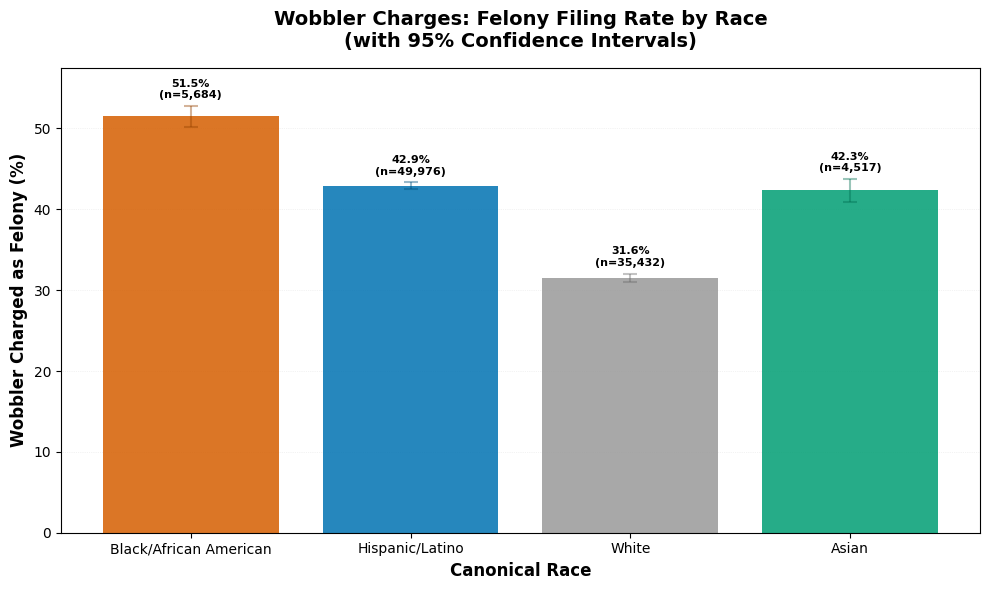

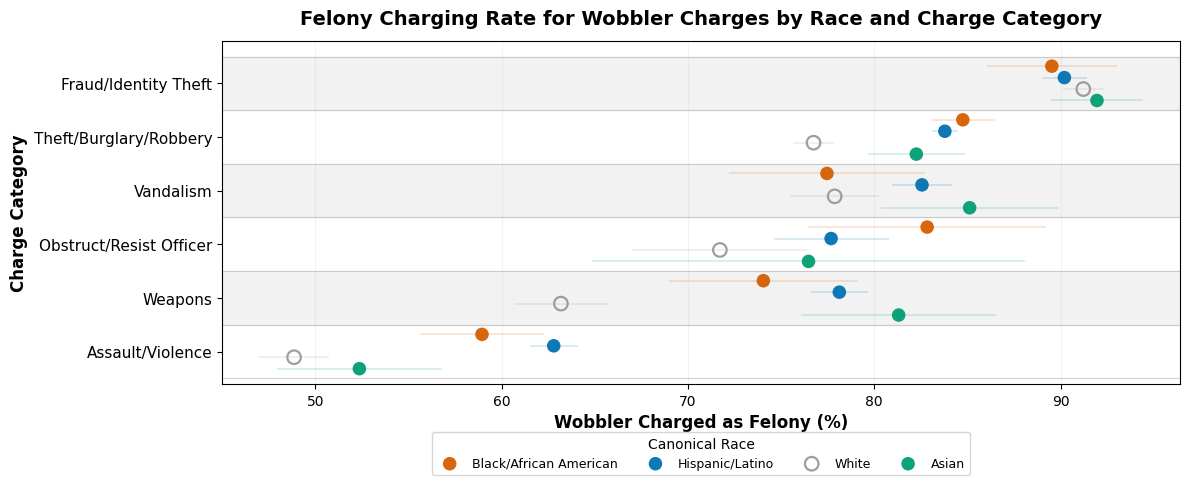

In [28]:
# Plot wobbler felony charge rates
fig1 = plot_wobbler_overall_felony_rate(substantive)

# Figure out which categories have over 500 total wobblers, have a wobbler felony charge rate of at least 50%, and exclude "Other"
wobbler_rates_by_category = wobbler_felony_rate_by_category(substantive)
wobbler_columns = wobbler_rates_by_category.index

# Plot wobbler felony charge rates by charge category
fig2 = plot_wobbler_cleveland_dot(substantive, top_categories=wobbler_columns, sort_by="total")

# export_figure_to_pdf(fig1, "wobbler_overall_felony_rate")
# export_figure_to_pdf(fig2, "wobbler_felony_rate_by_category")